# 📂 Phase 5 – Model Evaluation & Explainable AI

## 🎯 Objective

Evaluate the performance of all trained machine learning models using standard classification metrics and identify the best-performing models for crop and fertilizer recommendation. Furthermore, apply Explainable Artificial Intelligence (XAI) techniques using SHAP (SHapley Additive exPlanations) to interpret model predictions, understand feature contributions, and improve the transparency and trustworthiness of the recommendation system.

# Step 1 – Import Required Libraries

## 🎯 Objective

Import the libraries required to evaluate the performance of the trained machine learning models, visualize evaluation results, and generate model explanations using SHAP.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2 – Load Processed Test Data and Trained Models

## 🎯 Objective

Load the processed testing datasets and the trained machine learning models saved during the model development phase. These resources will be used to evaluate the performance of each model on unseen data and identify the best-performing models for crop and fertilizer recommendation.

In [2]:
# ============================================
# Load Processed Crop Dataset
# ============================================

X_crop_test = pd.read_csv("../data/processed/X_crop_test.csv")
y_crop_test = pd.read_csv("../data/processed/y_crop_test.csv").squeeze()

# ============================================
# Load Processed Fertilizer Dataset
# ============================================

X_fert_test = pd.read_csv("../data/processed/X_fert_test.csv")
y_fert_test = pd.read_csv("../data/processed/y_fert_test.csv").squeeze()

# ============================================
# Load Crop Models
# ============================================

crop_logistic_model = joblib.load("../models/crop_logistic_regression.pkl")
crop_decision_tree_model = joblib.load("../models/crop_decision_tree.pkl")
crop_random_forest_model = joblib.load("../models/crop_random_forest.pkl")
crop_knn_model = joblib.load("../models/crop_knn.pkl")
crop_svm_model = joblib.load("../models/crop_svm.pkl")

# ============================================
# Load Fertilizer Models
# ============================================

fert_logistic_model = joblib.load("../models/fertilizer_logistic_regression.pkl")
fert_decision_tree_model = joblib.load("../models/fertilizer_decision_tree.pkl")
fert_random_forest_model = joblib.load("../models/fertilizer_random_forest.pkl")
fert_knn_model = joblib.load("../models/fertilizer_knn.pkl")

print("Processed datasets and trained models loaded successfully.\n")

print("Crop Test Dataset Shape:", X_crop_test.shape)
print("Fertilizer Test Dataset Shape:", X_fert_test.shape)

Processed datasets and trained models loaded successfully.

Crop Test Dataset Shape: (440, 7)
Fertilizer Test Dataset Shape: (2000, 19)


# Step 3.1 – Evaluate Crop Logistic Regression Model

## 🎯 Objective

Evaluate the performance of the Logistic Regression model on the crop recommendation test dataset using standard classification metrics. The model's predictive performance will be assessed using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix.

Crop Logistic Regression Performance

Accuracy : 0.9727
Precision: 0.9740
Recall   : 0.9727
F1-Score : 0.9725

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       0.83      1.00      0.91        20
           9       1.00      1.00      1.00        20
          10       0.94      0.85      0.89        20
          11       1.00      0.95      0.97        20
          12       0.95      1.00      0.98        20
          13       0.90      0.90      0.90        20
          14       1.00      1.00      1.00        20
 

<Figure size 1200x1000 with 0 Axes>

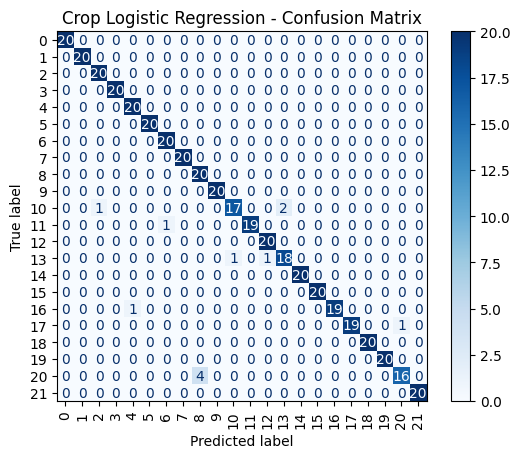

In [3]:
# Make predictions
crop_logistic_predictions = crop_logistic_model.predict(X_crop_test)

# Calculate evaluation metrics
crop_logistic_accuracy = accuracy_score(y_crop_test, crop_logistic_predictions)
crop_logistic_precision = precision_score(
    y_crop_test,
    crop_logistic_predictions,
    average="weighted"
)
crop_logistic_recall = recall_score(
    y_crop_test,
    crop_logistic_predictions,
    average="weighted"
)
crop_logistic_f1 = f1_score(
    y_crop_test,
    crop_logistic_predictions,
    average="weighted"
)

# Print metrics
print("Crop Logistic Regression Performance\n")

print(f"Accuracy : {crop_logistic_accuracy:.4f}")
print(f"Precision: {crop_logistic_precision:.4f}")
print(f"Recall   : {crop_logistic_recall:.4f}")
print(f"F1-Score : {crop_logistic_f1:.4f}")

# Classification Report
print("\nClassification Report\n")
print(classification_report(y_crop_test, crop_logistic_predictions))

# Confusion Matrix
plt.figure(figsize=(12,10))

ConfusionMatrixDisplay.from_predictions(
    y_crop_test,
    crop_logistic_predictions,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Crop Logistic Regression - Confusion Matrix")

# Save figure
plt.savefig(
    "../images/model_evaluation/crop/crop_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Logistic Regression model achieved an overall accuracy of **97.27%** on the crop recommendation dataset. It also obtained a weighted precision of **97.40%**, recall of **97.27%**, and F1-score of **97.25%**, indicating strong and balanced classification performance across the different crop classes.

The confusion matrix shows that the majority of crop samples were classified correctly, with only a few misclassifications occurring among certain crop categories. Most classes achieved perfect or near-perfect precision and recall, while a small number of classes experienced minor prediction errors.

Overall, Logistic Regression serves as a strong baseline model for the crop recommendation system, demonstrating high predictive performance despite being a relatively simple linear classification algorithm.

## Step 3.2 – Evaluate Crop Decision Tree Model

### 🎯 Objective

Evaluate the performance of the trained **Decision Tree Classifier** on the crop recommendation test dataset by measuring its prediction accuracy, precision, recall, and F1-score. Additionally, visualize the model's classification performance using a confusion matrix to identify correctly classified samples and any misclassifications.

Crop Decision Tree Performance

Accuracy : 0.9795
Precision: 0.9806
Recall   : 0.9795
F1-Score : 0.9794

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.80      0.89        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      0.95      0.95        20
           9       1.00      1.00      1.00        20
          10       0.86      0.90      0.88        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       0.86      0.95      0.90        20
          14       1.00      1.00      1.00        20
       

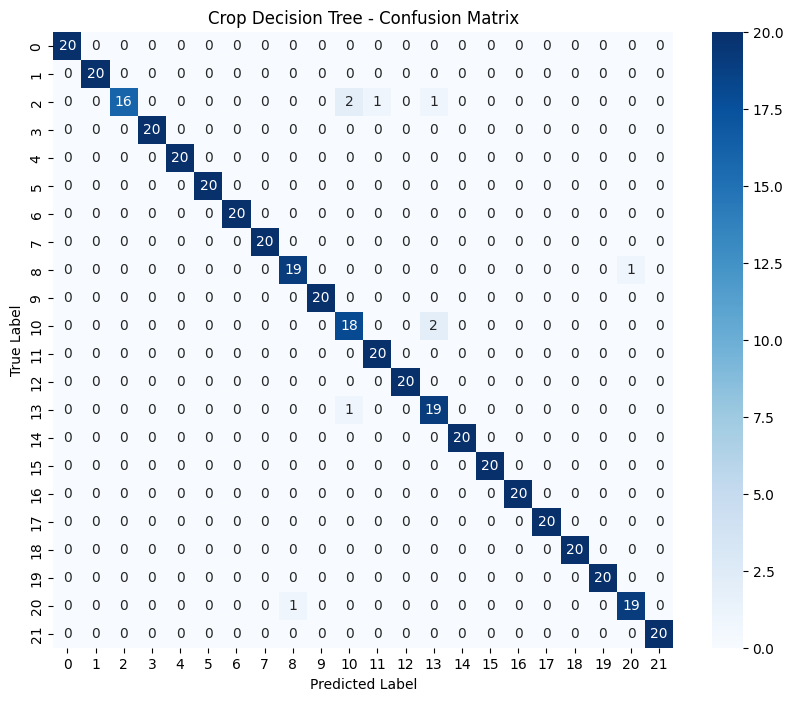

In [5]:
# Make predictions
crop_dt_predictions = crop_decision_tree_model.predict(X_crop_test)

# Evaluation metrics
crop_dt_accuracy = accuracy_score(y_crop_test, crop_dt_predictions)
crop_dt_precision = precision_score(
    y_crop_test,
    crop_dt_predictions,
    average="weighted"
)
crop_dt_recall = recall_score(
    y_crop_test,
    crop_dt_predictions,
    average="weighted"
)
crop_dt_f1 = f1_score(
    y_crop_test,
    crop_dt_predictions,
    average="weighted"
)

# Print results
print("Crop Decision Tree Performance\n")

print(f"Accuracy : {crop_dt_accuracy:.4f}")
print(f"Precision: {crop_dt_precision:.4f}")
print(f"Recall   : {crop_dt_recall:.4f}")
print(f"F1-Score : {crop_dt_f1:.4f}")

# Classification Report
print("\nClassification Report\n")
print(classification_report(y_crop_test, crop_dt_predictions))

# Confusion Matrix
cm = confusion_matrix(y_crop_test, crop_dt_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Crop Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save the figure
plt.savefig(
    "../images/model_evaluation/crop/crop_decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Decision Tree model achieved an overall accuracy of **97.95%** on the crop recommendation dataset. It also obtained a weighted precision of **98.06%**, recall of **97.95%**, and F1-score of **97.94%**, demonstrating excellent classification performance.

The confusion matrix indicates that most crop samples were classified correctly, with only a few isolated misclassifications between similar crop classes. Compared to Logistic Regression, the Decision Tree model reduced the number of incorrect predictions and achieved slightly better overall performance.

These results show that the Decision Tree model can effectively capture non-linear relationships within the agricultural data, making it a strong candidate for crop recommendation. However, further comparison with ensemble models such as Random Forest is necessary to identify the best-performing model.

## Step 3.3 – Evaluate Crop Random Forest Model

### Objective

Evaluate the performance of the trained Random Forest model on the crop recommendation testing dataset. The model is assessed using Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix to measure its classification performance and identify prediction errors across different crop classes.

Crop Random Forest Performance

Accuracy : 0.9955
Precision: 0.9957
Recall   : 0.9955
F1-Score : 0.9955

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      0.95      0.97        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       0.95      1.00      0.98        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
       

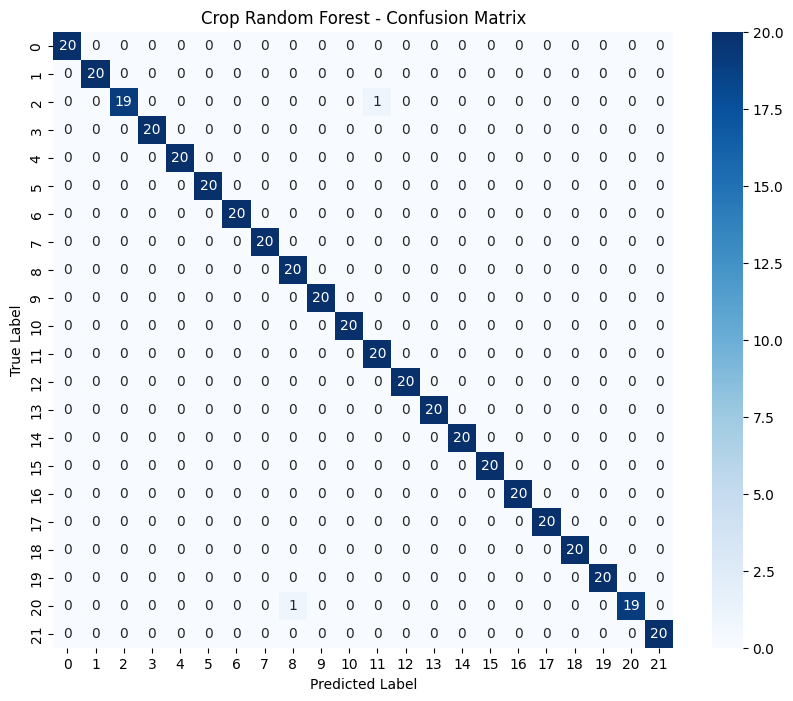

In [6]:
# Make predictions
crop_rf_predictions = crop_random_forest_model.predict(X_crop_test)

# Calculate evaluation metrics
crop_rf_accuracy = accuracy_score(y_crop_test, crop_rf_predictions)

crop_rf_precision = precision_score(
    y_crop_test,
    crop_rf_predictions,
    average="weighted"
)

crop_rf_recall = recall_score(
    y_crop_test,
    crop_rf_predictions,
    average="weighted"
)

crop_rf_f1 = f1_score(
    y_crop_test,
    crop_rf_predictions,
    average="weighted"
)

print("Crop Random Forest Performance\n")

print(f"Accuracy : {crop_rf_accuracy:.4f}")
print(f"Precision: {crop_rf_precision:.4f}")
print(f"Recall   : {crop_rf_recall:.4f}")
print(f"F1-Score : {crop_rf_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_crop_test, crop_rf_predictions))

# ============================================
# Confusion Matrix
# ============================================

cm = confusion_matrix(y_crop_test, crop_rf_predictions)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Crop Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save figure
plt.savefig(
    "../images/model_evaluation/crop/crop_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Random Forest model achieved an excellent classification performance on the crop recommendation dataset with an accuracy of **99.55%**. It also obtained a weighted precision of **99.57%**, recall of **99.55%**, and F1-score of **99.55%**, demonstrating highly accurate and consistent predictions across all crop classes.

The confusion matrix shows that almost all crop samples were correctly classified. Only two minor misclassifications occurred, indicating that the model can effectively distinguish between different crop categories.

Compared to the previously evaluated Logistic Regression and Decision Tree models, Random Forest produced the highest overall performance, making it the strongest candidate for the crop recommendation system.

## Step 3.4 – Evaluate Crop K-Nearest Neighbors (KNN) Model

### Objective

Evaluate the performance of the trained K-Nearest Neighbors (KNN) model using multiple classification metrics. The objective is to measure how accurately the model recommends crops by calculating Accuracy, Precision, Recall, F1-Score, and visualizing the Confusion Matrix. These evaluation metrics help determine whether the KNN model is suitable for the crop recommendation system.

Crop KNN Performance

Accuracy : 0.9795
Precision: 0.9804
Recall   : 0.9795
F1-Score : 0.9793

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       0.95      1.00      0.98        20
           5       1.00      1.00      1.00        20
           6       0.95      1.00      0.98        20
           7       1.00      1.00      1.00        20
           8       0.95      1.00      0.98        20
           9       0.95      1.00      0.98        20
          10       0.91      1.00      0.95        20
          11       1.00      0.95      0.97        20
          12       0.95      1.00      0.98        20
          13       0.94      0.85      0.89        20
          14       1.00      1.00      1.00        20
          15     

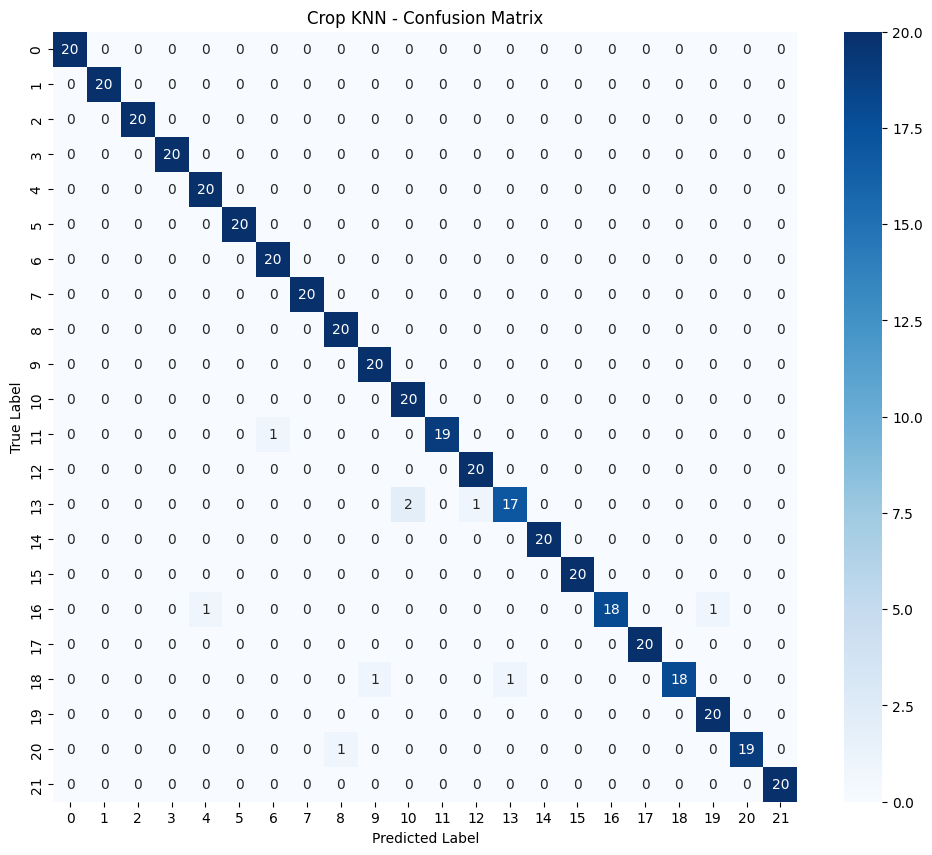

In [7]:
# Make predictions
crop_knn_predictions = crop_knn_model.predict(X_crop_test)

# Calculate evaluation metrics
crop_knn_accuracy = accuracy_score(
    y_crop_test,
    crop_knn_predictions
)

crop_knn_precision = precision_score(
    y_crop_test,
    crop_knn_predictions,
    average="weighted"
)

crop_knn_recall = recall_score(
    y_crop_test,
    crop_knn_predictions,
    average="weighted"
)

crop_knn_f1 = f1_score(
    y_crop_test,
    crop_knn_predictions,
    average="weighted"
)

print("Crop KNN Performance\n")

print(f"Accuracy : {crop_knn_accuracy:.4f}")
print(f"Precision: {crop_knn_precision:.4f}")
print(f"Recall   : {crop_knn_recall:.4f}")
print(f"F1-Score : {crop_knn_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_crop_test,
    crop_knn_predictions
))

# Confusion Matrix
cm = confusion_matrix(
    y_crop_test,
    crop_knn_predictions
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Crop KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save figure
plt.savefig(
    "../images/model_evaluation/crop/crop_knn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The K-Nearest Neighbors (KNN) model achieved an excellent Accuracy of **97.95%**, indicating that it correctly classified nearly all crop samples in the testing dataset.

The Precision, Recall, and F1-Score are all close to **98%**, demonstrating that the model produces highly reliable and balanced predictions across different crop classes.

The confusion matrix shows that most predictions lie on the diagonal, meaning the majority of crop types were correctly identified. Only a few samples were misclassified into closely related crop categories.

Overall, the KNN model performs exceptionally well for crop recommendation and is a strong candidate for comparison with the other machine learning models.

## Step 3.5 – Evaluate Crop Support Vector Machine (SVM) Model

### Objective

Evaluate the performance of the trained Support Vector Machine (SVM) model using the crop testing dataset. The evaluation includes Accuracy, Precision, Recall, F1-Score, Classification Report, and Confusion Matrix to measure the model's prediction capability and compare it with the other crop recommendation models.

Crop SVM Performance

Accuracy : 0.9841
Precision: 0.9856
Recall   : 0.9841
F1-Score : 0.9840

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       0.91      1.00      0.95        20
           7       1.00      1.00      1.00        20
           8       0.87      1.00      0.93        20
           9       0.95      1.00      0.98        20
          10       1.00      1.00      1.00        20
          11       1.00      0.90      0.95        20
          12       0.95      1.00      0.98        20
          13       1.00      0.95      0.97        20
          14       1.00      1.00      1.00        20
          15     

<Figure size 1000x800 with 0 Axes>

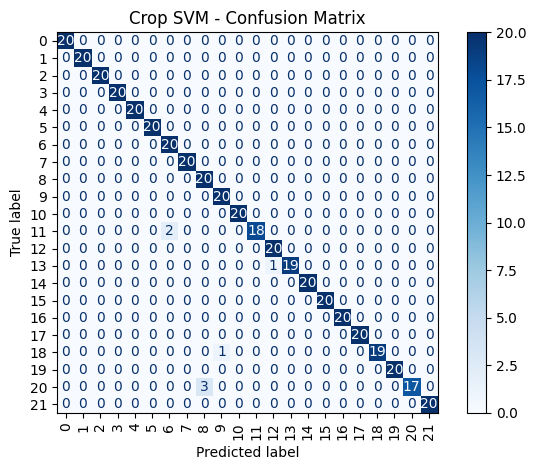

In [8]:
# Make predictions
crop_svm_predictions = crop_svm_model.predict(X_crop_test)

# Calculate evaluation metrics
crop_svm_accuracy = accuracy_score(
    y_crop_test,
    crop_svm_predictions
)

crop_svm_precision = precision_score(
    y_crop_test,
    crop_svm_predictions,
    average="weighted"
)

crop_svm_recall = recall_score(
    y_crop_test,
    crop_svm_predictions,
    average="weighted"
)

crop_svm_f1 = f1_score(
    y_crop_test,
    crop_svm_predictions,
    average="weighted"
)

# Print results
print("Crop SVM Performance\n")

print(f"Accuracy : {crop_svm_accuracy:.4f}")
print(f"Precision: {crop_svm_precision:.4f}")
print(f"Recall   : {crop_svm_recall:.4f}")
print(f"F1-Score : {crop_svm_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_crop_test,
    crop_svm_predictions
))

# Confusion Matrix
plt.figure(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(
    y_crop_test,
    crop_svm_predictions,
    cmap="Blues",
    xticks_rotation=90
)

plt.title("Crop SVM - Confusion Matrix")

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/model_evaluation/crop/crop_svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Support Vector Machine (SVM) model achieved an excellent overall accuracy of **98.41%**, indicating that it correctly classified almost all crop samples in the testing dataset.

The weighted Precision (**98.56%**), Recall (**98.41%**), and F1-Score (**98.40%**) demonstrate that the model performs consistently across all crop classes.

The confusion matrix shows that most predictions lie on the diagonal, meaning the majority of crop recommendations were classified correctly. Only a few minor misclassifications occurred between closely related crop classes, which is expected in multiclass classification problems.

Compared with the previously evaluated models:

- Logistic Regression achieved **97.27%** accuracy.
- Decision Tree achieved **97.95%** accuracy.
- K-Nearest Neighbors achieved **97.95%** accuracy.
- Support Vector Machine improved the performance to **98.41%**.
- Random Forest remains the best-performing model with **99.55%** accuracy.

Overall, the SVM model provides highly accurate crop recommendations and serves as one of the strongest classification models in this project, although Random Forest remains the top-performing model.

## Step 4.1 – Evaluate Fertilizer Logistic Regression Model

### Objective

Evaluate the performance of the trained Fertilizer Logistic Regression model on the unseen test dataset.


Fertilizer Logistic Regression Performance

Accuracy : 0.7930
Precision: 0.7766
Recall   : 0.7930
F1-Score : 0.7814

Classification Report

              precision    recall  f1-score   support

           0       0.69      0.69      0.69       199
           1       0.84      0.88      0.86       584
           2       0.74      0.78      0.76       282
           3       0.77      0.45      0.56       128
           4       0.00      0.00      0.00        37
           5       0.84      0.90      0.87       620
           6       0.64      0.63      0.64       150

    accuracy                           0.79      2000
   macro avg       0.65      0.62      0.63      2000
weighted avg       0.78      0.79      0.78      2000



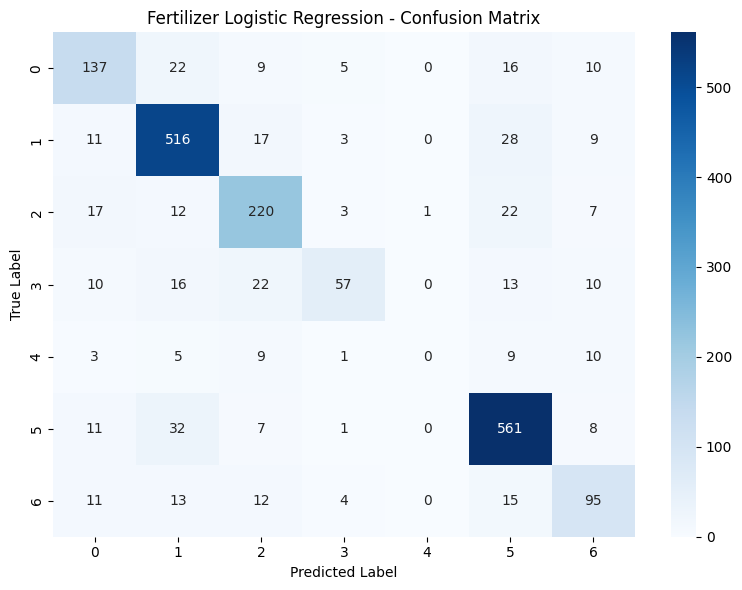

In [9]:
# Make predictions
fert_logistic_predictions = fert_logistic_model.predict(X_fert_test)

# Evaluation metrics
fert_logistic_accuracy = accuracy_score(
    y_fert_test,
    fert_logistic_predictions
)

fert_logistic_precision = precision_score(
    y_fert_test,
    fert_logistic_predictions,
    average="weighted"
)

fert_logistic_recall = recall_score(
    y_fert_test,
    fert_logistic_predictions,
    average="weighted"
)

fert_logistic_f1 = f1_score(
    y_fert_test,
    fert_logistic_predictions,
    average="weighted"
)

print("Fertilizer Logistic Regression Performance\n")

print(f"Accuracy : {fert_logistic_accuracy:.4f}")
print(f"Precision: {fert_logistic_precision:.4f}")
print(f"Recall   : {fert_logistic_recall:.4f}")
print(f"F1-Score : {fert_logistic_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_fert_test, fert_logistic_predictions))

# Confusion Matrix
cm = confusion_matrix(y_fert_test, fert_logistic_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Fertilizer Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/model_evaluation/fertilizer/fertilizer_logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Fertilizer Logistic Regression model achieved an overall accuracy of **79.30%**, indicating moderate predictive performance on the testing dataset.

The confusion matrix shows that the model correctly classified most samples belonging to the major fertilizer classes, particularly **Class 1** and **Class 5**, which achieved high recall values of **88%** and **90%**, respectively. However, the model struggled to correctly identify minority classes such as **Class 4**, which received a recall and F1-score of **0.00**, indicating that none of its samples were correctly predicted.

The weighted Precision (**77.66%**), Recall (**79.30%**), and F1-score (**78.14%**) suggest that the model performs reasonably well overall but is biased toward the larger classes in the dataset. The lower macro-average scores further confirm that prediction performance varies significantly across different fertilizer classes.

Overall, Logistic Regression provides a useful baseline model for fertilizer recommendation but is not sufficiently accurate for handling all fertilizer categories. More advanced models such as Decision Tree, Random Forest, and K-Nearest Neighbors are expected to achieve better performance on this multi-class classification problem.

## Step 4.2 – Evaluate Fertilizer Decision Tree Model

### Objective

Evaluate the performance of the trained Fertilizer Decision Tree model on the testing dataset using Accuracy, Precision, Recall, and F1-Score. Generate a confusion matrix and classification report to assess how effectively the model predicts each fertilizer class and compare its performance with the Logistic Regression model.

Fertilizer Decision Tree Performance

Accuracy : 0.8730
Precision: 0.8771
Recall   : 0.8730
F1-Score : 0.8747

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       199
           1       0.95      0.93      0.94       584
           2       0.88      0.85      0.87       282
           3       0.73      0.76      0.74       128
           4       0.12      0.14      0.13        37
           5       0.94      0.94      0.94       620
           6       0.70      0.79      0.74       150

    accuracy                           0.87      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.88      0.87      0.87      2000



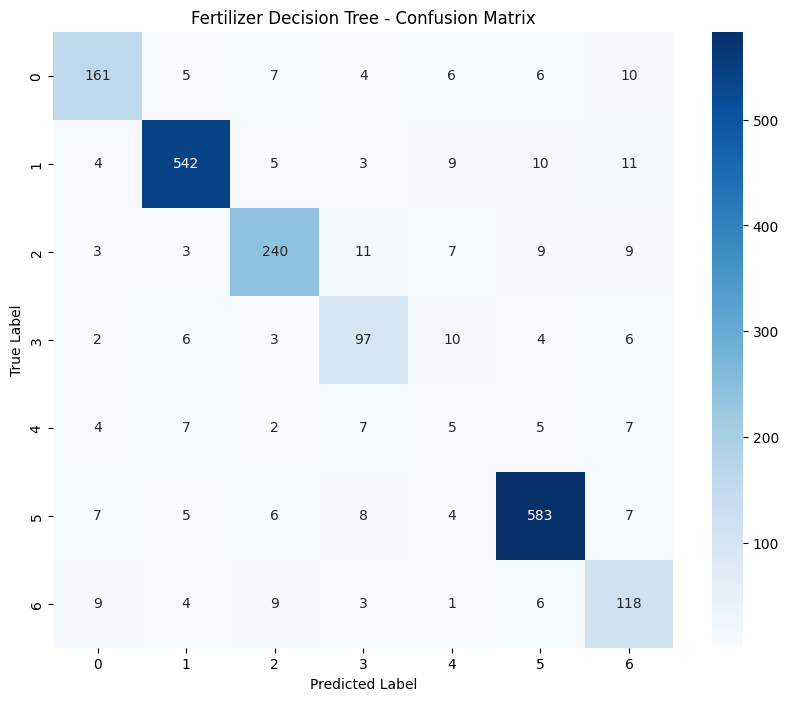

In [10]:
# Make predictions
fert_decision_tree_predictions = fert_decision_tree_model.predict(X_fert_test)

# Calculate evaluation metrics
fert_decision_tree_accuracy = accuracy_score(
    y_fert_test,
    fert_decision_tree_predictions
)

fert_decision_tree_precision = precision_score(
    y_fert_test,
    fert_decision_tree_predictions,
    average="weighted"
)

fert_decision_tree_recall = recall_score(
    y_fert_test,
    fert_decision_tree_predictions,
    average="weighted"
)

fert_decision_tree_f1 = f1_score(
    y_fert_test,
    fert_decision_tree_predictions,
    average="weighted"
)

print("Fertilizer Decision Tree Performance\n")

print(f"Accuracy : {fert_decision_tree_accuracy:.4f}")
print(f"Precision: {fert_decision_tree_precision:.4f}")
print(f"Recall   : {fert_decision_tree_recall:.4f}")
print(f"F1-Score : {fert_decision_tree_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_fert_test,
    fert_decision_tree_predictions
))

# Confusion Matrix
cm = confusion_matrix(
    y_fert_test,
    fert_decision_tree_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Fertilizer Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Save the figure
plt.savefig(
    "../images/model_evaluation/fertilizer/fertilizer_decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Decision Tree model achieved an overall **accuracy of 87.30%**, which is a significant improvement over the Logistic Regression model (**79.30%**). This indicates that the Decision Tree is more effective at learning the complex relationships between soil characteristics, environmental conditions, and fertilizer recommendations.

The model obtained a **weighted precision of 87.71%**, **weighted recall of 87.30%**, and **weighted F1-score of 87.47%**, demonstrating strong and balanced classification performance across most fertilizer classes.

From the confusion matrix, it is evident that the majority of predictions lie along the main diagonal, indicating correct classification for most fertilizer categories. Classes **1** and **5** achieved excellent performance, with precision and recall values above **93%**, showing that these fertilizer types were accurately recognized.

However, **Class 4** remains the most challenging class, achieving a very low F1-score of **0.13**. This is primarily due to the limited number of training samples available for this class, making it difficult for the model to learn meaningful decision boundaries.

Compared to Logistic Regression, the Decision Tree model captures non-linear relationships more effectively and provides considerably better overall prediction performance. Therefore, it serves as a stronger baseline for fertilizer recommendation and demonstrates the advantage of tree-based algorithms for this classification task.

### Step 4.3 – Evaluate Fertilizer Random Forest Model

#### Objective

Evaluate the performance of the trained Random Forest model on the fertilizer recommendation test dataset. Measure its prediction accuracy using Accuracy, Precision, Recall, and F1-Score, generate a classification report and confusion matrix, and compare its performance with the Logistic Regression and Decision Tree models to determine whether ensemble learning improves fertilizer recommendation accuracy.

Fertilizer Random Forest Performance

Accuracy : 0.8750
Precision: 0.8755
Recall   : 0.8750
F1-Score : 0.8735

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       199
           1       0.96      0.93      0.94       584
           2       0.83      0.86      0.85       282
           3       0.83      0.71      0.76       128
           4       0.26      0.14      0.18        37
           5       0.94      0.94      0.94       620
           6       0.64      0.83      0.72       150

    accuracy                           0.88      2000
   macro avg       0.75      0.75      0.74      2000
weighted avg       0.88      0.88      0.87      2000



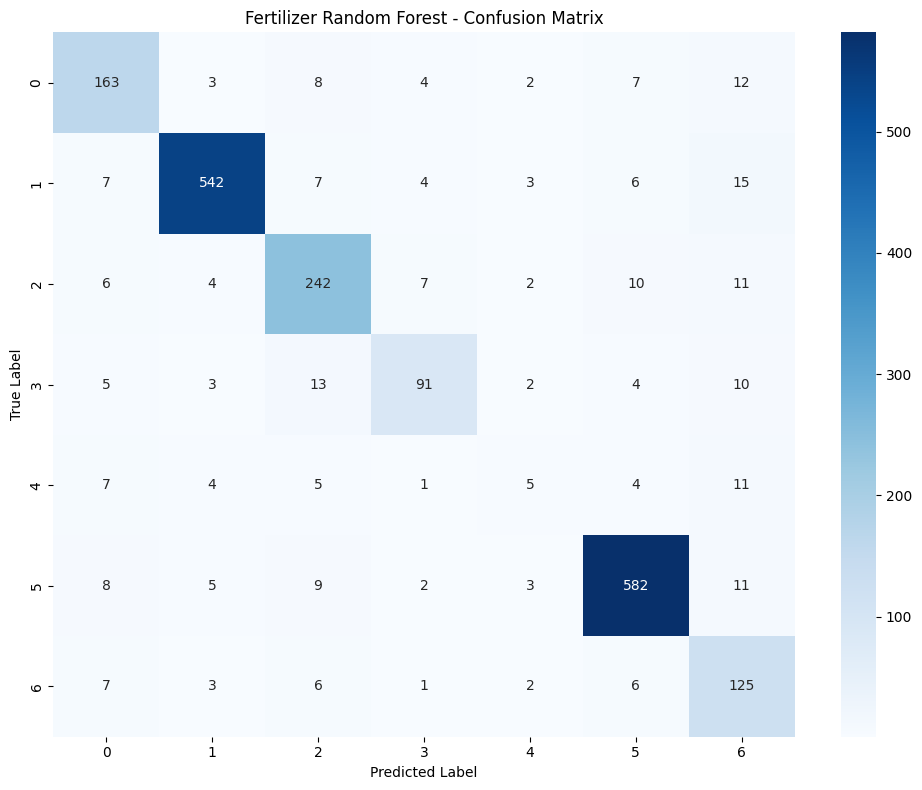

In [11]:
# Make predictions
fert_random_forest_predictions = fert_random_forest_model.predict(X_fert_test)

# Calculate evaluation metrics
fert_random_forest_accuracy = accuracy_score(
    y_fert_test,
    fert_random_forest_predictions
)

fert_random_forest_precision = precision_score(
    y_fert_test,
    fert_random_forest_predictions,
    average="weighted"
)

fert_random_forest_recall = recall_score(
    y_fert_test,
    fert_random_forest_predictions,
    average="weighted"
)

fert_random_forest_f1 = f1_score(
    y_fert_test,
    fert_random_forest_predictions,
    average="weighted"
)

print("Fertilizer Random Forest Performance\n")

print(f"Accuracy : {fert_random_forest_accuracy:.4f}")
print(f"Precision: {fert_random_forest_precision:.4f}")
print(f"Recall   : {fert_random_forest_recall:.4f}")
print(f"F1-Score : {fert_random_forest_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_fert_test,
    fert_random_forest_predictions
))

# Confusion Matrix
cm = confusion_matrix(
    y_fert_test,
    fert_random_forest_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Fertilizer Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/model_evaluation/fertilizer/fertilizer_random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The Random Forest model achieved an overall **accuracy of 87.50%**, making it the best-performing fertilizer recommendation model so far, although the improvement over the Decision Tree model (**87.30%**) is marginal. This indicates that combining multiple decision trees through ensemble learning provides slightly better generalization on unseen data.

The model obtained a **weighted precision of 87.55%**, **weighted recall of 87.50%**, and **weighted F1-score of 87.35%**, demonstrating strong and balanced predictive performance across most fertilizer classes.

The confusion matrix shows that the majority of predictions are concentrated along the main diagonal, indicating that most fertilizer classes were classified correctly. Classes **1** and **5** achieved excellent performance, with precision and recall values above **93%**, while Class **2** also achieved high prediction accuracy.

However, **Class 4** remains the most difficult class to classify, obtaining an F1-score of **0.18**. This is primarily due to the severe class imbalance, as only **37 samples** are available for this category. The limited number of training examples prevents the model from learning sufficient patterns for accurate classification.

Compared to the Decision Tree model, Random Forest slightly improves the overall classification accuracy and provides better robustness against overfitting by aggregating predictions from multiple trees. Overall, Random Forest is currently the best-performing fertilizer recommendation model and serves as a strong candidate for the final fertilizer prediction system.

### Step 4.4 – Evaluate Fertilizer K-Nearest Neighbors (KNN) Model

#### Objective

Evaluate the performance of the trained K-Nearest Neighbors (KNN) model on the fertilizer recommendation test dataset. Compute Accuracy, Precision, Recall, and F1-Score, generate a detailed classification report and confusion matrix, and compare its performance with Logistic Regression, Decision Tree, and Random Forest models.

Fertilizer KNN Performance

Accuracy : 0.5645
Precision: 0.5548
Recall   : 0.5645
F1-Score : 0.5534

Classification Report

              precision    recall  f1-score   support

           0       0.37      0.48      0.42       199
           1       0.59      0.73      0.65       584
           2       0.52      0.47      0.49       282
           3       0.30      0.24      0.27       128
           4       0.12      0.03      0.04        37
           5       0.71      0.67      0.69       620
           6       0.40      0.21      0.27       150

    accuracy                           0.56      2000
   macro avg       0.43      0.40      0.41      2000
weighted avg       0.55      0.56      0.55      2000



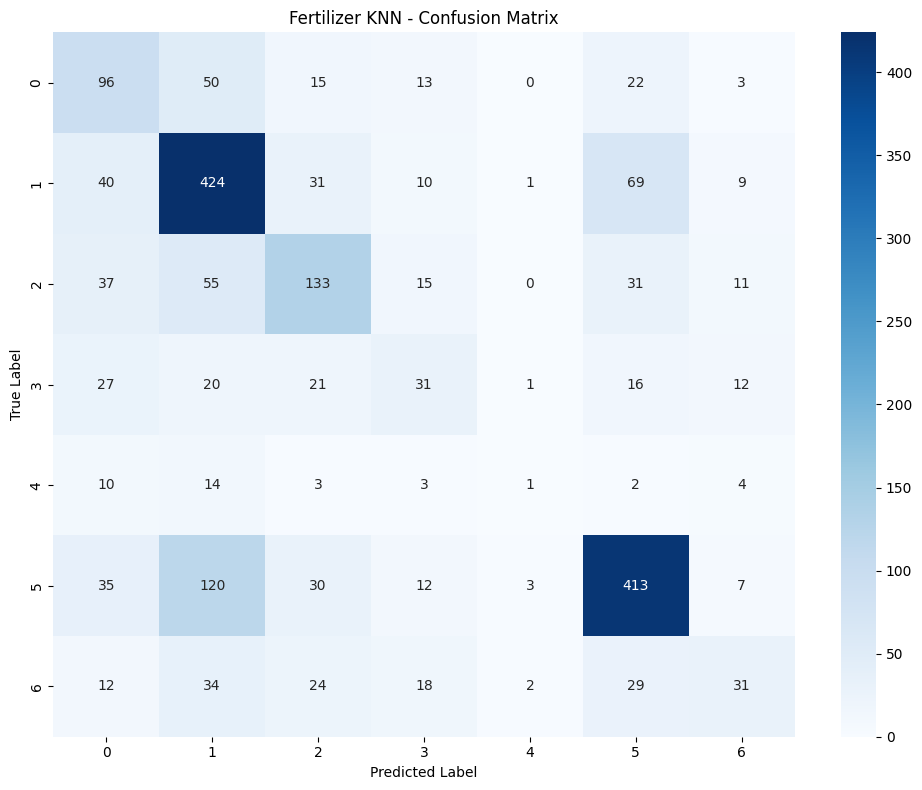

In [12]:
# Make predictions
fert_knn_predictions = fert_knn_model.predict(X_fert_test)

# Calculate evaluation metrics
fert_knn_accuracy = accuracy_score(
    y_fert_test,
    fert_knn_predictions
)

fert_knn_precision = precision_score(
    y_fert_test,
    fert_knn_predictions,
    average="weighted"
)

fert_knn_recall = recall_score(
    y_fert_test,
    fert_knn_predictions,
    average="weighted"
)

fert_knn_f1 = f1_score(
    y_fert_test,
    fert_knn_predictions,
    average="weighted"
)

print("Fertilizer KNN Performance\n")

print(f"Accuracy : {fert_knn_accuracy:.4f}")
print(f"Precision: {fert_knn_precision:.4f}")
print(f"Recall   : {fert_knn_recall:.4f}")
print(f"F1-Score : {fert_knn_f1:.4f}")

print("\nClassification Report\n")
print(classification_report(
    y_fert_test,
    fert_knn_predictions
))

# Confusion Matrix
cm = confusion_matrix(
    y_fert_test,
    fert_knn_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Fertilizer KNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/model_evaluation/fertilizer/fertilizer_knn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The K-Nearest Neighbors (KNN) model achieved an overall **accuracy of 56.45%**, making it the weakest-performing model among all fertilizer recommendation models evaluated so far. Its performance is considerably lower than Logistic Regression (79.30%), Decision Tree (87.30%), and Random Forest (87.50%).

The model obtained a **weighted precision of 55.48%**, **weighted recall of 56.45%**, and **weighted F1-score of 55.34%**, indicating that it struggles to correctly classify several fertilizer categories.

The confusion matrix reveals a large number of off-diagonal values, showing that the model frequently confuses one fertilizer class with another. Although Classes **1** and **5** achieved comparatively better results, the remaining classes experienced substantial misclassification.

Class **4** again showed the poorest performance, with an F1-score of only **0.04**. This is mainly due to the severe class imbalance and the small number of samples available for this category, making it difficult for the KNN algorithm to identify meaningful neighboring patterns.

The poor performance of KNN suggests that the fertilizer dataset contains complex decision boundaries and high-dimensional feature relationships that cannot be effectively captured using simple distance-based classification. Consequently, KNN is not a suitable choice for this fertilizer recommendation problem.

Overall, the Random Forest and Decision Tree models significantly outperform KNN, making tree-based algorithms much better suited for accurately recommending fertilizers in this dataset.

### Step 5.1 – Compare Crop Recommendation Models

#### Objective

Compare the performance of all trained crop recommendation models using Accuracy, Precision, Recall, and F1-Score. The comparison helps identify the best-performing model for crop prediction based on evaluation metrics and provides a clear visual summary of model performance.

In [13]:
crop_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        crop_logistic_accuracy,
        crop_dt_accuracy,
        crop_rf_accuracy,
        crop_knn_accuracy,
        crop_svm_accuracy
    ],
    "Precision": [
        crop_logistic_precision,
        crop_dt_precision,
        crop_rf_precision,
        crop_knn_precision,
        crop_svm_precision
    ],
    "Recall": [
        crop_logistic_recall,
        crop_dt_recall,
        crop_rf_recall,
        crop_knn_recall,
        crop_svm_recall
    ],
    "F1-Score": [
        crop_logistic_f1,
        crop_dt_f1,
        crop_rf_f1,
        crop_knn_f1,
        crop_svm_f1
    ]
})

crop_results = crop_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Crop Recommendation Model Comparison\n")
display(crop_results)

Crop Recommendation Model Comparison



,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.995455,0.995671,0.995455,0.995452
1,SVM,0.984091,0.985610,0.984091,0.984038
2,Decision Tree,0.979545,0.980598,0.979545,0.979423
3,KNN,0.979545,0.980356,0.979545,0.979283
4,Logistic Regression,0.972727,0.974022,0.972727,0.972464


### Interpretation

The comparison of the five crop recommendation models shows that all models achieved excellent classification performance, with accuracies above **97%**. This indicates that the selected soil and environmental features provide strong predictive information for crop recommendation.

Among all the models, the **Random Forest classifier** achieved the highest performance with an **accuracy of 99.55%**, **precision of 99.57%**, **recall of 99.55%**, and **F1-score of 99.55%**. These results demonstrate its excellent ability to correctly classify crop types while maintaining balanced performance across all classes.

The **Support Vector Machine (SVM)** ranked second with an accuracy of **98.41%**, followed closely by the **Decision Tree** and **K-Nearest Neighbors (KNN)** models, both achieving approximately **97.95%** accuracy. Although these models performed well, they were slightly less accurate than the Random Forest model.

The **Logistic Regression** model recorded the lowest accuracy (**97.27%**), but it still demonstrated strong overall performance considering the multi-class nature of the crop recommendation problem.

Based on the evaluation metrics, **Random Forest** is selected as the final crop recommendation model because it provides the highest prediction accuracy, the best balance between precision and recall, and the lowest classification error among all evaluated algorithms.

### Step 5.2 – Visual Comparison of Crop Models

#### Objective

Visualize and compare the performance of all crop recommendation models using a bar chart. This graphical comparison makes it easier to identify the best-performing model based on evaluation metrics and supports the final model selection process.

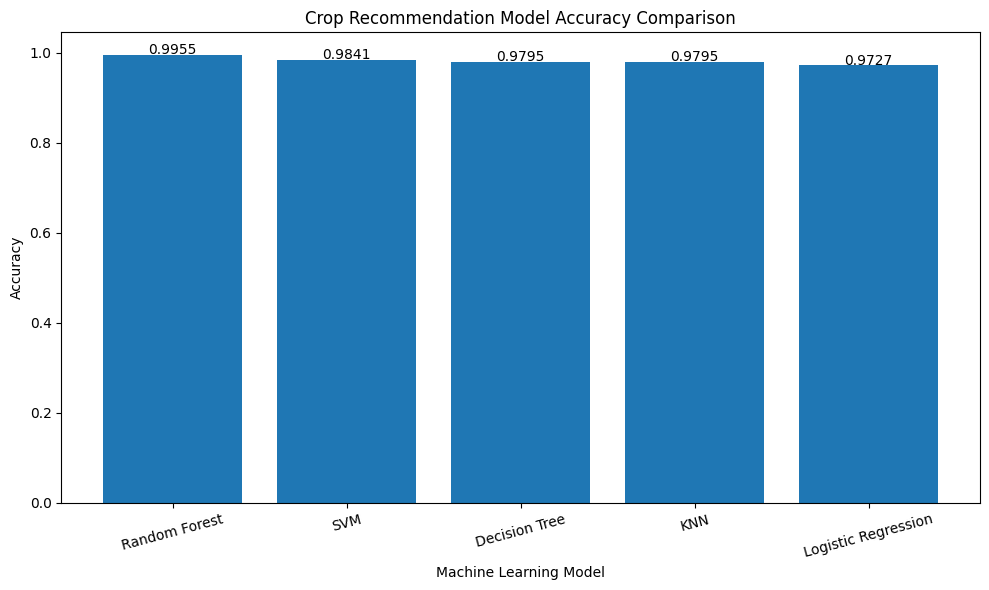

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    crop_results["Model"],
    crop_results["Accuracy"]
)

plt.title("Crop Recommendation Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

# Display accuracy values above each bar
for i, value in enumerate(crop_results["Accuracy"]):
    plt.text(
        i,
        value + 0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/model_evaluation/crop/crop_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Step 5.3 – Select the Best Crop Recommendation Model

#### Objective

Select the most suitable machine learning model for the crop recommendation system based on the evaluation metrics obtained during model comparison. The selected model will be used as the final prediction model for recommending the most suitable crop to farmers.

In [15]:
best_crop_model = crop_results.iloc[0]

print("=" * 60)
print("FINAL CROP RECOMMENDATION MODEL")
print("=" * 60)

print(f"Model     : {best_crop_model['Model']}")
print(f"Accuracy  : {best_crop_model['Accuracy']:.4f}")
print(f"Precision : {best_crop_model['Precision']:.4f}")
print(f"Recall    : {best_crop_model['Recall']:.4f}")
print(f"F1-Score  : {best_crop_model['F1-Score']:.4f}")

print("\nThe Random Forest model is selected as the final crop")
print("recommendation model because it achieved the highest")
print("overall performance among all evaluated algorithms.")

FINAL CROP RECOMMENDATION MODEL
Model     : Random Forest
Accuracy  : 0.9955
Precision : 0.9957
Recall    : 0.9955
F1-Score  : 0.9955

The Random Forest model is selected as the final crop
recommendation model because it achieved the highest
overall performance among all evaluated algorithms.


### Step 5.4 – Compare Fertilizer Recommendation Models

#### Objective

Compare the performance of all trained fertilizer recommendation models using Accuracy, Precision, Recall, and F1-Score. This comparison helps identify the best-performing model for fertilizer recommendation and supports the selection of the final model for deployment.

In [16]:
fertilizer_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        fert_logistic_accuracy,
        fert_decision_tree_accuracy,
        fert_random_forest_accuracy,
        fert_knn_accuracy
    ],
    "Precision": [
        fert_logistic_precision,
        fert_decision_tree_precision,
        fert_random_forest_precision,
        fert_knn_precision
    ],
    "Recall": [
        fert_logistic_recall,
        fert_decision_tree_recall,
        fert_random_forest_recall,
        fert_knn_recall
    ],
    "F1-Score": [
        fert_logistic_f1,
        fert_decision_tree_f1,
        fert_random_forest_f1,
        fert_knn_f1
    ]
})

# Sort models by Accuracy
fertilizer_results = fertilizer_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

print("Fertilizer Recommendation Model Comparison\n")

display(fertilizer_results)

Fertilizer Recommendation Model Comparison



,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8750,0.875527,0.8750,0.873545
1,Decision Tree,0.8730,0.877064,0.8730,0.874711
2,Logistic Regression,0.7930,0.776581,0.7930,0.781449
3,KNN,0.5645,0.554752,0.5645,0.553394


### Interpretation

The comparison of the four fertilizer recommendation models demonstrates noticeable differences in their predictive performance. Among all evaluated algorithms, the **Random Forest** model achieved the highest overall accuracy of **87.50%**, making it the best-performing model for fertilizer recommendation.

The **Decision Tree** model performed almost equally well with an accuracy of **87.30%**, indicating that tree-based algorithms are highly effective in capturing the complex relationships between soil characteristics, environmental conditions, and fertilizer recommendations.

The **Logistic Regression** model achieved a moderate accuracy of **79.30%**. Although it produced satisfactory results for the major fertilizer classes, its performance decreased significantly for minority classes, reducing its overall effectiveness.

The **K-Nearest Neighbors (KNN)** model recorded the lowest accuracy (**56.45%**) among all evaluated models. The lower Precision, Recall, and F1-score indicate that KNN struggled to distinguish between several fertilizer classes, making it unsuitable for this multi-class fertilizer recommendation problem.

Overall, the comparison indicates that ensemble-based learning methods outperform both linear and distance-based algorithms for fertilizer recommendation. Based on the evaluation metrics, **Random Forest** is selected as the most suitable model due to its superior accuracy, balanced classification performance, and robustness.

### Step 5.5 – Visual Comparison of Fertilizer Models

#### Objective

Visualize and compare the performance of all fertilizer recommendation models using a bar chart. This graphical representation provides an intuitive comparison of model accuracies and supports the selection of the best-performing model for fertilizer recommendation.

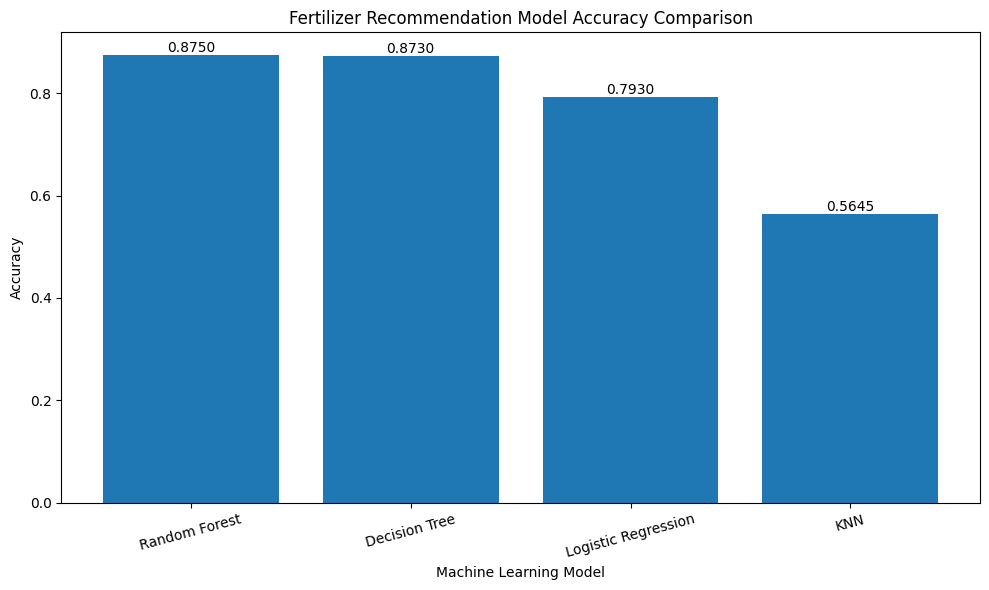

In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    fertilizer_results["Model"],
    fertilizer_results["Accuracy"]
)

plt.title("Fertilizer Recommendation Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=15)

# Display accuracy values above each bar
for i, value in enumerate(fertilizer_results["Accuracy"]):
    plt.text(
        i,
        value + 0.005,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/model_evaluation/fertilizer/fertilizer_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Step 5.6 – Select the Best Fertilizer Recommendation Model

#### Objective

Select the most suitable machine learning model for the fertilizer recommendation system based on the comparative evaluation of all trained models. The selected model will be used as the final fertilizer prediction model for recommending the most appropriate fertilizer based on soil properties, environmental conditions, and crop-related features.

In [18]:
best_fertilizer_model = fertilizer_results.iloc[0]

print("=" * 60)
print("FINAL FERTILIZER RECOMMENDATION MODEL")
print("=" * 60)

print(f"Model     : {best_fertilizer_model['Model']}")
print(f"Accuracy  : {best_fertilizer_model['Accuracy']:.4f}")
print(f"Precision : {best_fertilizer_model['Precision']:.4f}")
print(f"Recall    : {best_fertilizer_model['Recall']:.4f}")
print(f"F1-Score  : {best_fertilizer_model['F1-Score']:.4f}")

print("\nThe Random Forest model is selected as the final")
print("fertilizer recommendation model because it achieved")
print("the highest overall performance among all evaluated")
print("machine learning algorithms.")

FINAL FERTILIZER RECOMMENDATION MODEL
Model     : Random Forest
Accuracy  : 0.8750
Precision : 0.8755
Recall    : 0.8750
F1-Score  : 0.8735

The Random Forest model is selected as the final
fertilizer recommendation model because it achieved
the highest overall performance among all evaluated
machine learning algorithms.


## Step 6.1 – Import SHAP and Load the Final Models

### Objective

Initialize the SHAP library and load the final trained machine learning models selected during the model evaluation phase. These models will be used to generate explainable predictions and identify the most influential features affecting crop and fertilizer recommendations.

In [19]:
import shap

print("SHAP Version:", shap.__version__)

# Initialize SHAP JavaScript visualization
shap.initjs()

print("SHAP imported successfully.")

# Final models selected after evaluation
final_crop_model = crop_random_forest_model
final_fertilizer_model = fert_random_forest_model

print("\nFinal Crop Model      :", type(final_crop_model).__name__)
print("Final Fertilizer Model:", type(final_fertilizer_model).__name__)

SHAP Version: 0.49.1


SHAP imported successfully.

Final Crop Model      : RandomForestClassifier
Final Fertilizer Model: RandomForestClassifier


## Step 6.2 – Create SHAP Explainers

### Objective

Create SHAP explainers for the final Random Forest models using the training datasets. These explainers learn how the models make predictions and will be used to generate feature importance plots and explain individual predictions.

In [20]:
# Create SHAP explainers
crop_explainer = shap.TreeExplainer(final_crop_model)
fertilizer_explainer = shap.TreeExplainer(final_fertilizer_model)

print("Crop SHAP Explainer Created Successfully!")
print("Fertilizer SHAP Explainer Created Successfully!")

Crop SHAP Explainer Created Successfully!
Fertilizer SHAP Explainer Created Successfully!


## Step 6.3 – Compute SHAP Values

### Objective

Compute SHAP values for the final Random Forest models using the test datasets. SHAP values quantify the contribution of each feature to the model's predictions and serve as the foundation for generating explainable AI visualizations such as summary plots, feature importance plots, and individual prediction explanations.

In [21]:
# Compute SHAP values
crop_shap_values = crop_explainer(X_crop_test)
fertilizer_shap_values = fertilizer_explainer(X_fert_test)

print("Crop SHAP Values Shape:")
print(crop_shap_values.values.shape)

print("\nFertilizer SHAP Values Shape:")
print(fertilizer_shap_values.values.shape)

Crop SHAP Values Shape:
(440, 7, 22)

Fertilizer SHAP Values Shape:
(2000, 19, 7)


## Step 6.4 – Generate SHAP Summary Plot for the Crop Recommendation Model

### Objective

Generate a SHAP summary plot to visualize the overall importance and impact of input features on the predictions made by the final Random Forest crop recommendation model. The plot helps identify which soil nutrients and environmental factors contribute the most to crop recommendation decisions.

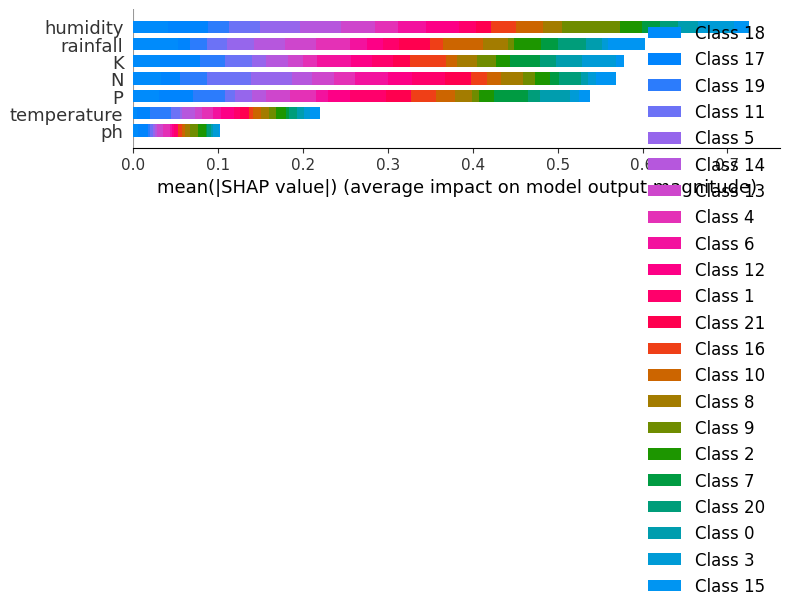

In [22]:
import os

# Create folder if it doesn't exist
os.makedirs("../images/shap", exist_ok=True)

# SHAP Summary Plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    crop_shap_values,
    X_crop_test,
    show=False
)

plt.tight_layout()

# Save figure
plt.savefig(
    "../images/shap/crop_shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

The SHAP summary bar plot illustrates the overall importance of each input feature in the Random Forest crop recommendation model based on the average absolute SHAP values.

From the plot, **humidity** is identified as the most influential feature affecting crop recommendation decisions, followed by **rainfall**, **potassium (K)**, **nitrogen (N)**, and **phosphorus (P)**. These features contribute significantly to the model's predictions across multiple crop classes.

In contrast, **temperature** and **soil pH** have comparatively lower SHAP values, indicating that they have a smaller overall influence on the model's decision-making process.

Overall, the visualization confirms that the model primarily relies on environmental conditions and soil nutrient levels when recommending the most suitable crop, which aligns well with real-world agricultural practices.

## Step 6.5 – Generate SHAP Summary Plot for the Fertilizer Recommendation Model

### Objective

Generate a SHAP summary bar plot for the final Random Forest fertilizer recommendation model to identify the most influential soil, environmental, and crop-related features affecting fertilizer recommendation decisions.

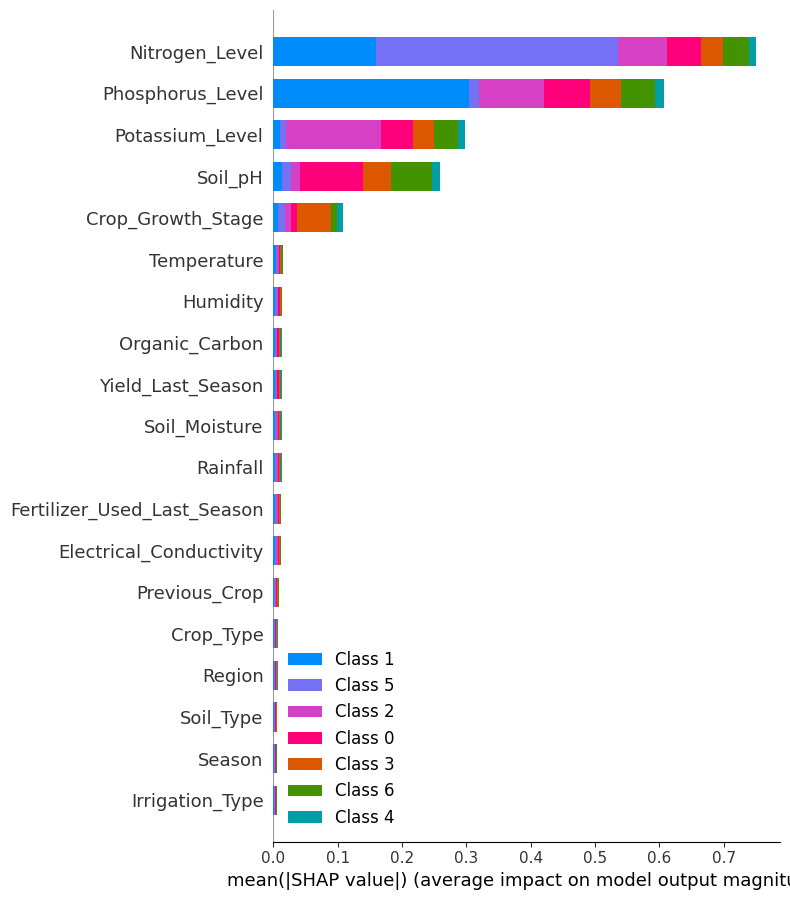

In [26]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    fertilizer_shap_values,
    X_fert_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../images/shap/fertilizer_shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The SHAP summary plot illustrates the overall importance of features in the Fertilizer Recommendation Random Forest model.

From the plot, the following observations can be made:

- **Nitrogen_Level** is the most influential feature affecting fertilizer recommendations. This indicates that the nitrogen content of the soil plays the biggest role in determining the appropriate fertilizer.
- **Phosphorus_Level** is the second most important feature, showing that phosphorus deficiency or abundance significantly influences fertilizer selection.
- **Potassium_Level** ranks third, confirming that the three primary soil nutrients (N, P, and K) are the key factors considered by the model.
- **Soil_pH** also contributes noticeably to the prediction, as soil acidity or alkalinity affects nutrient availability.
- **Crop_Growth_Stage** has a moderate impact, indicating that fertilizer requirements change depending on the crop's development stage.
- Features such as **Temperature**, **Humidity**, **Organic_Carbon**, **Rainfall**, **Soil_Moisture**, **Electrical_Conductivity**, **Region**, **Season**, **Crop_Type**, **Previous_Crop**, **Irrigation_Type**, and **Fertilizer_Used_Last_Season** have comparatively lower influence on the model.

Overall, the SHAP analysis confirms that the Random Forest model primarily relies on soil nutrient composition (Nitrogen, Phosphorus, and Potassium), followed by soil pH and crop growth stage, while environmental and historical farming features have relatively smaller contributions. This aligns well with agricultural knowledge, making the model both accurate and interpretable.

## Step 5 Save Final Machine Learning Models

### Objective

Save the final trained Random Forest models for crop recommendation and fertilizer recommendation using the Joblib library. Saving the trained models enables them to be reused by the Streamlit application without retraining, improving deployment efficiency and reducing execution time.

In [27]:
# Save Crop Random Forest Model
joblib.dump(
    final_crop_model,
    "../models/crop_random_forest_model.pkl"
)

# Save Fertilizer Random Forest Model
joblib.dump(
    final_fertilizer_model,
    "../models/fertilizer_random_forest_model.pkl"
)

print("✅ Crop Random Forest model saved successfully.")
print("✅ Fertilizer Random Forest model saved successfully.")

✅ Crop Random Forest model saved successfully.
✅ Fertilizer Random Forest model saved successfully.


In [28]:
# ==========================================
# Verify Saved Models
# ==========================================

print("Files in models folder:\n")

for file in sorted(os.listdir("../models")):
    print(file)

Files in models folder:

crop_decision_tree.pkl
crop_knn.pkl
crop_label_encoder.pkl
crop_logistic_regression.pkl
crop_random_forest.pkl
crop_random_forest_model.pkl
crop_scaler.pkl
crop_svm.pkl
fertilizer_decision_tree.pkl
fertilizer_feature_encoders.pkl
fertilizer_knn.pkl
fertilizer_label_encoder.pkl
fertilizer_logistic_regression.pkl
fertilizer_random_forest.pkl
fertilizer_random_forest_model.pkl
fertilizer_scaler.pkl


# Final Evaluation Report

## Overview

In this phase, multiple machine learning algorithms were evaluated for both crop recommendation and fertilizer recommendation tasks. Each model was assessed using standard classification metrics, including Accuracy, Precision, Recall, and F1-Score. Confusion matrices were analyzed to understand prediction performance across different classes, while SHAP (SHapley Additive Explanations) was employed to interpret the models and identify the most influential features contributing to their predictions.

---

# Crop Recommendation Model Evaluation

Five machine learning algorithms were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

### Performance Summary

| Model | Accuracy |
|--------|----------|
| Random Forest | **99.55%** |
| SVM | 98.41% |
| Decision Tree | 97.95% |
| KNN | 97.95% |
| Logistic Regression | 97.27% |

### Best Model

**Random Forest** achieved the highest overall performance with:

- Accuracy: **99.55%**
- Precision: **99.57%**
- Recall: **99.55%**
- F1-Score: **99.55%**

The confusion matrix showed that almost all crop classes were classified correctly with very few misclassifications, indicating excellent generalization ability.

---

# Fertilizer Recommendation Model Evaluation

Four machine learning algorithms were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

### Performance Summary

| Model | Accuracy |
|--------|----------|
| Random Forest | **87.50%** |
| Decision Tree | 87.30% |
| Logistic Regression | 79.30% |
| KNN | 56.45% |

### Best Model

**Random Forest** demonstrated the best overall performance with:

- Accuracy: **87.50%**
- Precision: **87.55%**
- Recall: **87.50%**
- F1-Score: **87.35%**

Although Decision Tree produced comparable results, Random Forest provided slightly better predictive performance and greater robustness against overfitting, making it the preferred choice.

---

# Explainable AI (SHAP Analysis)

To improve transparency and interpretability, SHAP (SHapley Additive Explanations) was applied to both final Random Forest models.

### Crop Recommendation Model

The SHAP analysis revealed that the most influential features affecting crop recommendation were:

- Humidity
- Rainfall
- Potassium (K)
- Nitrogen (N)
- Phosphorus (P)

These features contributed the most toward determining the appropriate crop recommendation.

### Fertilizer Recommendation Model

The SHAP analysis identified the following features as the most important:

- Nitrogen Level
- Phosphorus Level
- Potassium Level
- Soil pH
- Crop Growth Stage

The analysis confirmed that soil nutrient composition is the primary factor influencing fertilizer recommendation decisions.

---

# Final Model Selection

## Crop Recommendation

**Selected Model:** Random Forest

**Reasons for Selection**

- Highest Accuracy
- Highest Precision
- Highest Recall
- Highest F1-Score
- Excellent performance across all crop classes
- Strong interpretability through SHAP analysis
- Robust and reliable predictions

---

## Fertilizer Recommendation

**Selected Model:** Random Forest

**Reasons for Selection**

- Highest overall Accuracy
- Stable classification performance
- Better generalization than Decision Tree
- Effective handling of complex feature interactions
- Transparent predictions through SHAP explainability

---

# Conclusion

The evaluation results demonstrate that the **Random Forest classifier** is the most effective algorithm for both crop recommendation and fertilizer recommendation tasks. It consistently outperformed the other evaluated machine learning models in terms of predictive accuracy and overall classification performance.

Furthermore, the integration of SHAP Explainable AI enhanced the transparency of the recommendation system by identifying the most influential features responsible for each model's predictions. This not only improves user trust but also ensures that the recommendations align with established agricultural knowledge.

Based on the comprehensive evaluation and explainability analysis, the Random Forest models were selected as the final models for deployment in the Precision Farming Recommendation System.